First 5 Rows of Dataset:
   Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0           1             230.1                 37.8                     69.2   
1           2              44.5                 39.3                     45.1   
2           3              17.2                 45.9                     69.3   
3           4             151.5                 41.3                     58.5   
4           5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3

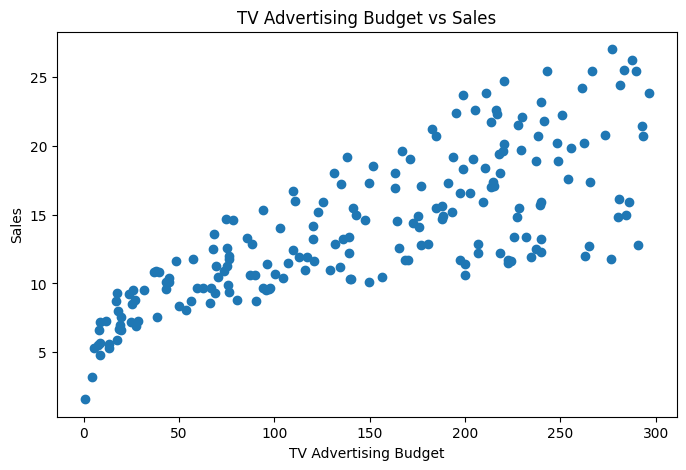


Model Training Completed Successfully

Predicted Sales Values:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]

Model Evaluation Metrics
Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
Root Mean Squared Error: 1.78159966153345
R2 Score: 0.899438024100912


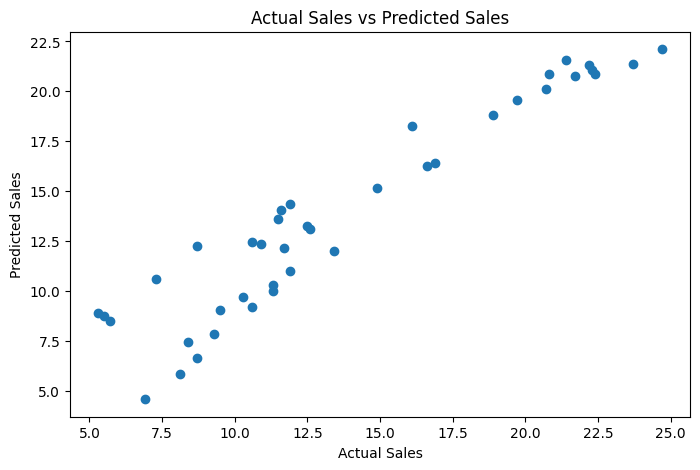


Future Sales Prediction:
Predicted Sales = 21.784471161504115

Prediction Results Saved Successfully


In [1]:
# ==========================================
# Predictive Analytics Using Historical Data
# ==========================================

# STEP 1 - Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# STEP 2 - Load Dataset
# ==========================================

# Load CSV File
data = pd.read_csv("Advertising Budget and Sales.csv")

# Display First 5 Rows
print("First 5 Rows of Dataset:")
print(data.head())

# ==========================================
# STEP 3 - Dataset Information
# ==========================================

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# ==========================================
# STEP 4 - Data Visualization
# ==========================================

# Scatter Plot - TV vs Sales

plt.figure(figsize=(8,5))

plt.scatter(data['TV Ad Budget ($)'], data['Sales ($)'])

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising Budget vs Sales")

plt.savefig("tv_vs_sales.png")

plt.show()

# ==========================================
# STEP 5 - Feature Selection
# ==========================================

# Input Features
X = data[['TV Ad Budget ($)',
          'Radio Ad Budget ($)',
          'Newspaper Ad Budget ($)']]

# Target Variable
y = data['Sales ($)']

# ==========================================
# STEP 6 - Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# STEP 7 - Train Machine Learning Model
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")

# ==========================================
# STEP 8 - Make Predictions
# ==========================================

predictions = model.predict(X_test)

print("\nPredicted Sales Values:")
print(predictions[:10])

# ==========================================
# STEP 9 - Evaluate Model Performance
# ==========================================

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\nModel Evaluation Metrics")

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

# ==========================================
# STEP 10 - Visualization of Predictions
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual Sales vs Predicted Sales")

plt.savefig("prediction_graph.png")

plt.show()

# ==========================================
# STEP 11 - Predict Future Sales
# ==========================================

# Example Future Advertising Budget

future_data = pd.DataFrame({
    'TV Ad Budget ($)': [250],
    'Radio Ad Budget ($)': [40],
    'Newspaper Ad Budget ($)': [20]
})

future_prediction = model.predict(future_data)

print("\nFuture Sales Prediction:")

print("Predicted Sales =", future_prediction[0])

# ==========================================
# STEP 12 - Save Predictions to CSV
# ==========================================

results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

results.to_csv("sales_predictions.csv", index=False)

print("\nPrediction Results Saved Successfully")

# ==========================================
# PROJECT COMPLETED
# ==========================================